# Module 1 — Recommandation de culture

Dans ce notebook, l’objectif est de déterminer quelle culture recommander à partir de 7 caractéristiques du sol et du climat : N, P, K, température, humidité, pH et pluviométrie.

## 1) Imports
On commence par importer les bibliothèques utiles pour manipuler les données, entraîner les modèles et visualiser les résultats.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

## 2) Configuration
Ici, on fixe les éléments de base du projet : les variables d’entrée, la cible, la graine aléatoire et la répartition entre entraînement, validation et test.

In [2]:
FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
TARGET = "label"
SEED = 42
TEST_SIZE = 0.15
VAL_SIZE = 0.15

DATA_PATH = "../datasets/crop_recommendation/crop_recommendation_dataset.csv"

## 3) Chargement des données
On charge ensuite le dataset pour vérifier rapidement sa taille, ses statistiques principales et l’éventuelle présence de valeurs manquantes.

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Shape : {df.shape}")
print(df.describe())

Shape : (30530, 8)
                  N             P             K   temperature      humidity  \
count  30530.000000  30530.000000  30530.000000  30530.000000  30530.000000   
mean      67.318959     49.229495     53.992459     24.624678     73.534671   
std       37.817408     20.130845     40.141726      5.624915     15.386077   
min        0.000000      0.000000      0.000000      0.008489      0.241239   
25%       42.146217     39.278988     24.000000     20.891188     65.135813   
50%       60.453968     45.753459     45.000000     25.460000     78.953720   
75%       89.894356     60.000000     71.171207     28.500000     83.621437   
max      194.789434    150.000000    500.000000     46.732778     99.748924   

                 ph      rainfall  
count  30530.000000  30530.000000  
mean       6.264561    604.738930  
std        0.784655    527.626778  
min        3.504752      0.000000  
25%        5.620000    107.413725  
50%        6.344240    579.750000  
75%        6.7386

In [4]:
# check valeurs manquantes
print(df[FEATURES + [TARGET]].isnull().sum())

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


## Corrélations
Cette matrice aide à repérer les variables qui évoluent ensemble et donne une première intuition sur la structure des données.

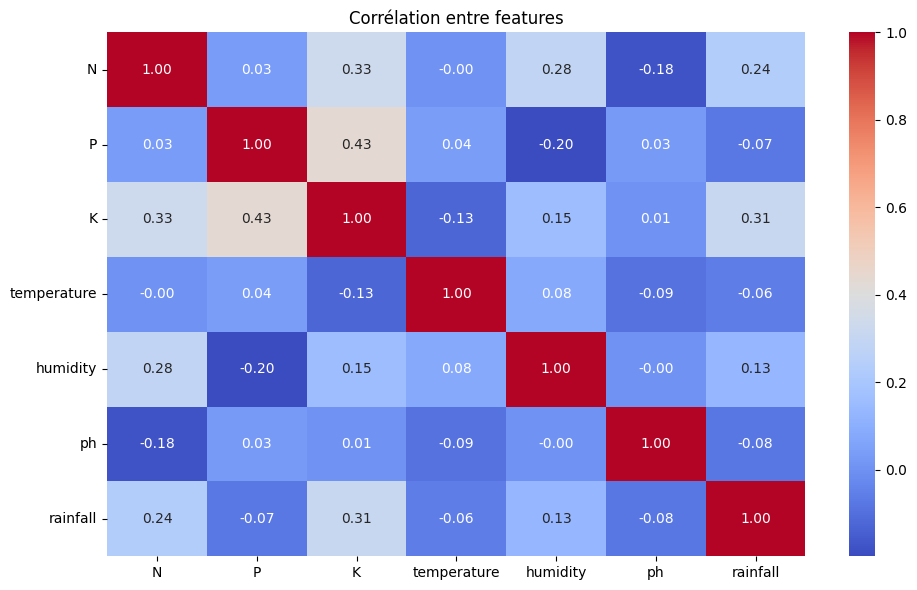

In [5]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[FEATURES].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélation entre features")
plt.tight_layout()
plt.show()

## Chevauchement des distributions

En regardant les histogrammes, on constate que plusieurs cultures se recouvrent fortement sur les différentes variables. Autrement dit, de simples règles fixes ne suffisent pas vraiment, ce qui justifie l’usage d’un modèle de machine learning.

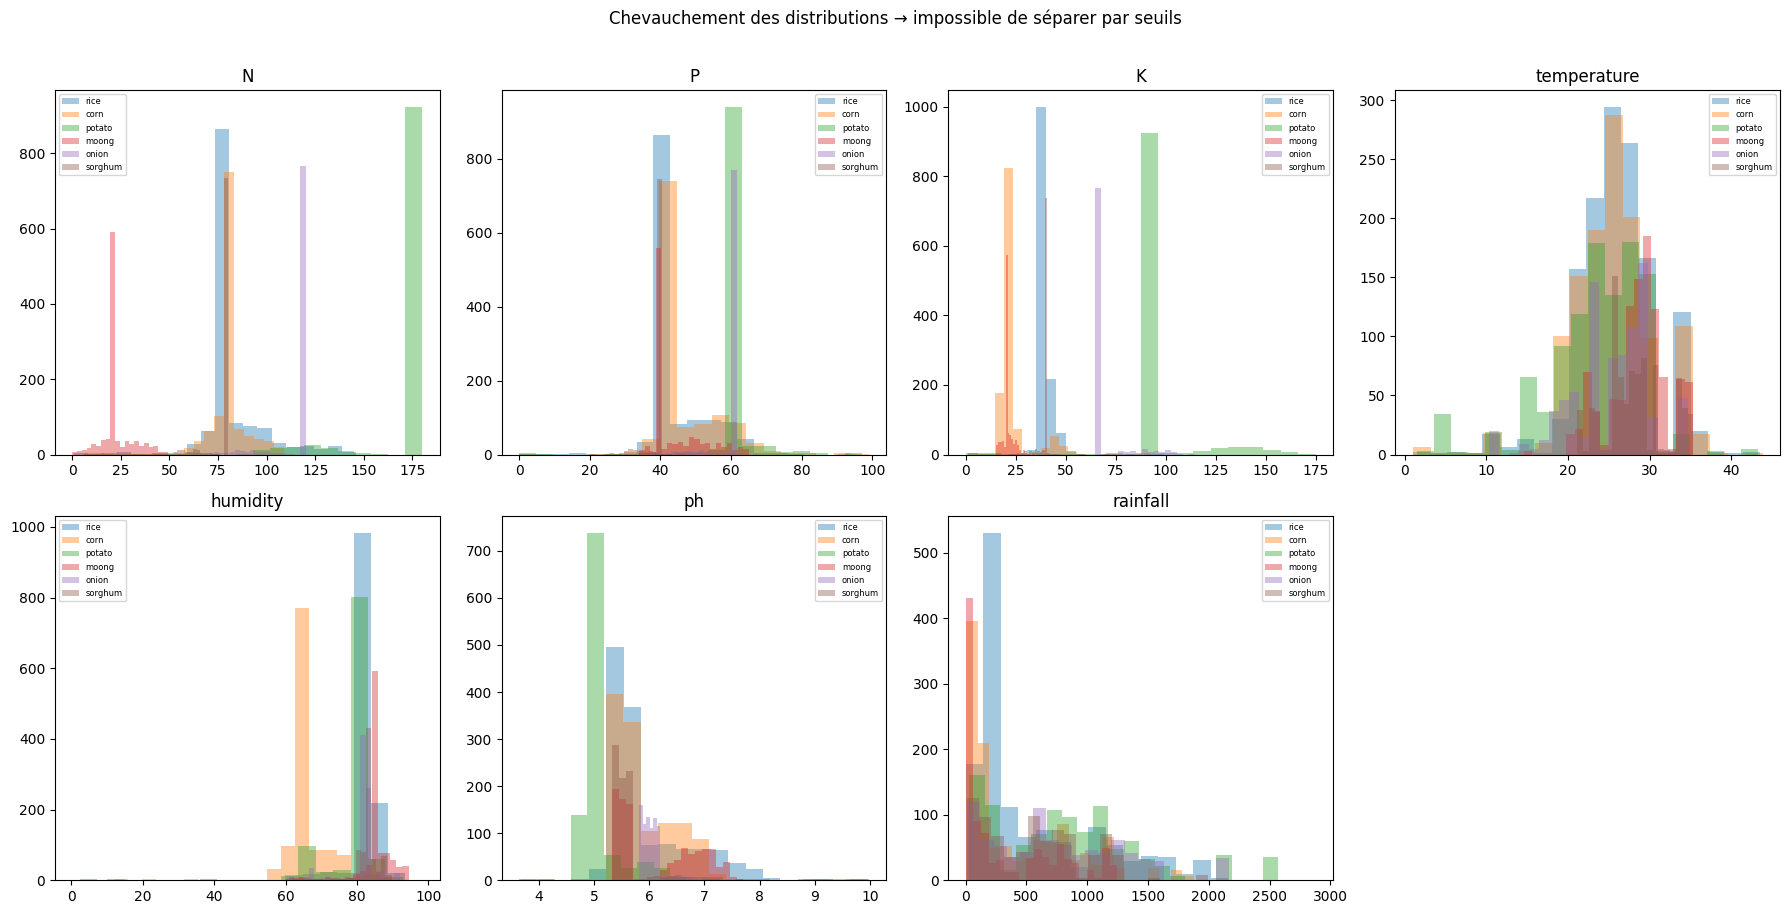

In [6]:
# chevauchement des distributions : pourquoi des regles simples ne marchent pas
sample_crops = df[TARGET].value_counts().index[:6]
df_sample = df[df[TARGET].isin(sample_crops)]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    for crop in sample_crops:
        subset = df_sample[df_sample[TARGET] == crop]
        axes[i].hist(subset[col], bins=20, alpha=0.4, label=crop)
    axes[i].set_title(col)
    axes[i].legend(fontsize=6)

axes[-1].axis("off")
plt.suptitle("Chevauchement des distributions → impossible de séparer par seuils", y=1.01)
plt.tight_layout()
plt.show()

## 4) Prétraitement et définition des modèles
À cette étape, on sépare les données en trois jeux — entraînement, validation et test — puis on construit un pipeline simple avant de comparer plusieurs modèles.

In [7]:
X = df[FEATURES]
y = df[TARGET]

# split 70/15/15
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=VAL_SIZE + TEST_SIZE, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),
    random_state=SEED, stratify=y_tmp
)
print(f"train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")

# pipeline preprocessing : imputation médiane + scaling
num_cols = X.select_dtypes(include="number").columns.tolist()
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), num_cols),
], remainder="drop")

models = {
    "LogReg": LogisticRegression(max_iter=3000, random_state=SEED),
    "SVM": SVC(kernel="rbf", random_state=SEED),
    "RF": RandomForestClassifier(n_estimators=300, random_state=SEED),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "DTree": DecisionTreeClassifier(random_state=SEED),
}

train=21371  val=4579  test=4580


## 5) Entraînement et métriques
Chaque modèle est entraîné sur le jeu d’apprentissage, puis comparé uniquement sur le jeu de validation. Le jeu de test est gardé pour la vérification finale du modèle retenu.

In [16]:
results = {}
labels = sorted(y.unique())

for name, clf in models.items():
    pipeline = Pipeline([("prep", preprocessor), ("clf", clf)])
    pipeline.fit(X_train, y_train)

    # évaluation sur le jeu de validation uniquement
    yv = pipeline.predict(X_val)

    results[name] = {
        "val_acc": accuracy_score(y_val, yv),
        "val_f1": f1_score(y_val, yv, average="weighted"),
        "pipeline": pipeline,
    }

metrics_df = pd.DataFrame([
    {"model": k, **{m: v[m] for m in ["val_acc", "val_f1"]}}
    for k, v in results.items()
]).sort_values("val_f1", ascending=False)

print(metrics_df)

    model   val_acc    val_f1
2      RF  0.919196  0.918982
4   DTree  0.875955  0.876075
3     KNN  0.811094  0.813926
1     SVM  0.800393  0.799035
0  LogReg  0.633108  0.617207


## 5a) Choix du meilleur modèle
Ici, les 15 % de validation sont utilisés pour comparer les modèles entre eux. Concrètement, après l’entraînement sur le jeu d’apprentissage, chaque modèle prédit sur X_val, puis on calcule val_acc et val_f1. C’est sur cette base qu’on retient le meilleur modèle, avant de passer une seule fois au jeu de test.

In [18]:
best_model_name = metrics_df.iloc[0]["model"]
best_pipeline = results[best_model_name]["pipeline"]

print(f"Meilleur modèle retenu sur validation : {best_model_name}")
print(f"Validation F1 : {results[best_model_name]['val_f1']:.4f}")
print(f"Validation accuracy : {results[best_model_name]['val_acc']:.4f}")
print("\nLe jeu de test est gardé pour la vérification finale.")

Meilleur modèle retenu sur validation : RF
Validation F1 : 0.9190
Validation accuracy : 0.9192

Le jeu de test est gardé pour la vérification finale.


## 5b) Optimisation du Random Forest
On teste ensuite une version optimisée du Random Forest avec une recherche d’hyperparamètres. Le choix final se fait sur la validation, puis on vérifie une seule fois sur le jeu de test.

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [None, 20, 40],
    "clf__min_samples_split": [2, 5],
}

rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(random_state=SEED)),
])

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring="f1_weighted", n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur F1 (cv) : {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Meilleurs paramètres : {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
Meilleur F1 (cv) : 0.8951


In [20]:
# comparaison du RF optimisé avec le RF baseline sur la validation
best_rf = grid_search.best_estimator_

yv_opt = best_rf.predict(X_val)
rf_val_acc = accuracy_score(y_val, yv_opt)
rf_val_f1 = f1_score(y_val, yv_opt, average='weighted')

print("Comparaison sur le jeu de validation :")
print(f"RF optimisé — val_acc={rf_val_acc:.4f}  val_f1={rf_val_f1:.4f}")
print(f"RF baseline — val_acc={results['RF']['val_acc']:.4f}  val_f1={results['RF']['val_f1']:.4f}")

final_model_name = best_model_name
final_pipeline = best_pipeline

if rf_val_f1 > results['RF']['val_f1']:
    final_model_name = "RF optimisé"
    final_pipeline = best_rf

yt_final = final_pipeline.predict(X_test)
final_test_acc = accuracy_score(y_test, yt_final)
final_test_f1 = f1_score(y_test, yt_final, average='weighted')
final_cm = confusion_matrix(y_test, yt_final, labels=labels)

print(f"\nModèle final retenu : {final_model_name}")
print("Évaluation finale sur le jeu de test :")
print(f"Test accuracy={final_test_acc:.4f}")
print(f"Test F1={final_test_f1:.4f}")

Comparaison sur le jeu de validation :
RF optimisé — val_acc=0.9192  val_f1=0.9190
RF baseline — val_acc=0.9192  val_f1=0.9190

Modèle final retenu : RF
Évaluation finale sur le jeu de test :
Test accuracy=0.9140
Test F1=0.9139


## 6) Visualisations
On visualise ici les performances sur le jeu de validation pour comparer les modèles, puis la matrice de confusion du modèle final sur le jeu de test.

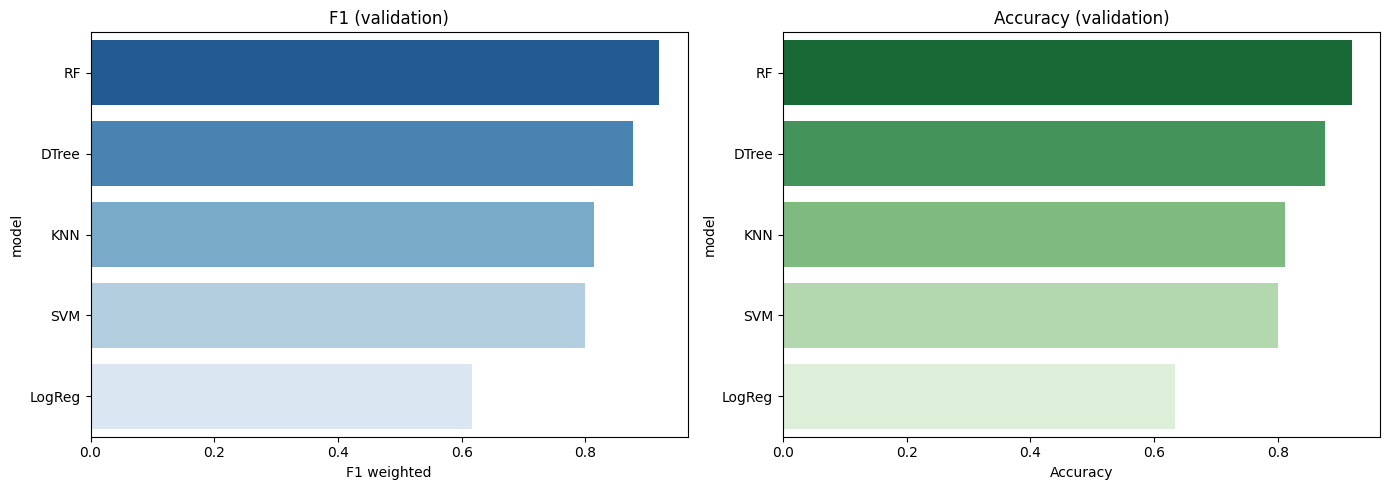

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ordered = metrics_df.sort_values("val_f1", ascending=False)
sns.barplot(data=ordered, x="val_f1", y="model", hue="model", palette="Blues_r", legend=False, ax=ax1)
ax1.set_title("F1 (validation)")
ax1.set_xlabel("F1 weighted")

sns.barplot(data=ordered, x="val_acc", y="model", hue="model", palette="Greens_r", legend=False, ax=ax2)
ax2.set_title("Accuracy (validation)")
ax2.set_xlabel("Accuracy")

plt.tight_layout()
plt.show()

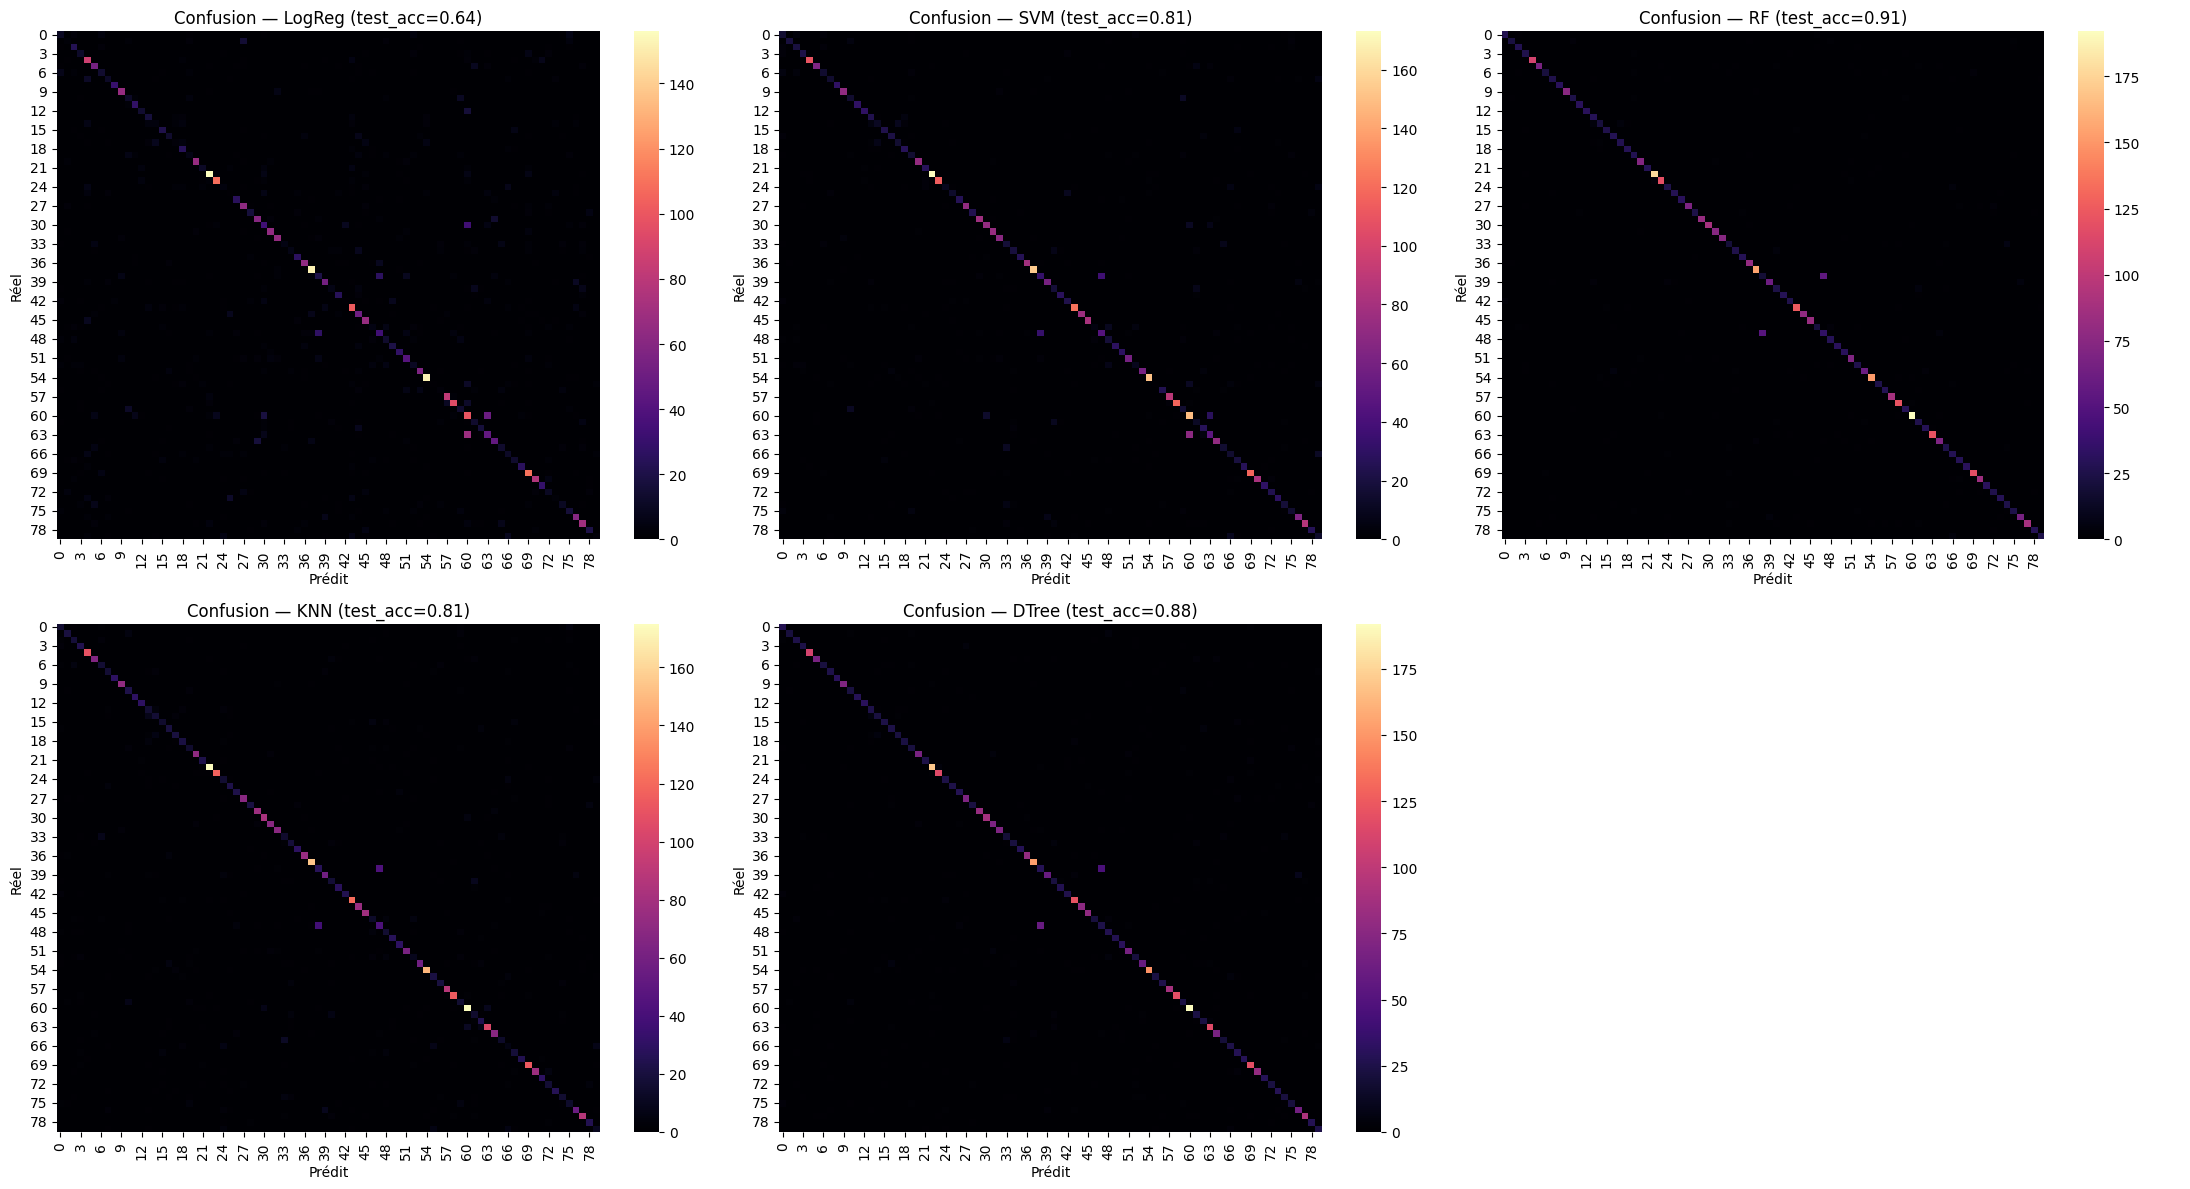

In [ ]:
# matrice de confusion du modèle final sur le jeu de test
plt.figure(figsize=(10, 8))
sns.heatmap(final_cm, cmap="magma")
plt.title(f"Confusion — {final_model_name} (test_acc={final_test_acc:.2f})")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()

## 7) Prédiction vs réalité du modèle final
Cette dernière étape permet d’afficher, sur le jeu de test, quelques prédictions du modèle finalement retenu afin de voir concrètement où il réussit et où il se trompe.

In [ ]:
comp = pd.DataFrame({
    "réalité": y_test.values,
    "prédiction": yt_final,
})

comp["correct"] = comp["réalité"] == comp["prédiction"]
comp.head(20)

,réalité,pred_LogReg,ok_LogReg,pred_SVM,ok_SVM,pred_RF,ok_RF,pred_KNN,ok_KNN,pred_DTree,ok_DTree
0,watermelon,potato,False,watermelon,True,watermelon,True,zucchini,False,watermelon,True
1,barley,safflower,False,barley,True,barley,True,oat,False,barley,True
2,moong,moong,True,moong,True,moong,True,moong,True,moong,True
3,chickpea,chickpea,True,chickpea,True,chickpea,True,chickpea,True,chickpea,True
4,potato,potato,True,potato,True,potato,True,potato,True,potato,True
5,wheat,wheat,True,wheat,True,wheat,True,wheat,True,wheat,True
6,rapeseed,rapeseed,True,rapeseed,True,rapeseed,True,rapeseed,True,rapeseed,True
7,banana,taro,False,banana,True,banana,True,banana,True,banana,True
8,asparagus,asparagus,True,asparagus,True,cherry,False,raspberry,False,asparagus,True
9,rice,rice,True,rice,True,rice,True,rice,True,rice,True


In [ ]:
print(f"Accuracy finale du modèle retenu : {comp['correct'].mean():.4f}")

LogReg     : 0.6424
SVM        : 0.8052
RF         : 0.9140
KNN        : 0.8144
DTree      : 0.8762


## 8) Sauvegarde du modèle
Pour terminer, on enregistre le modèle final avec son pipeline de prétraitement, les colonnes utilisées et les métriques obtenues. Cela permet de le réutiliser ensuite dans l’application.

In [ ]:
import joblib
from pathlib import Path

model_output_path = Path("../models/random_forest_crop_model.joblib")
model_output_path.parent.mkdir(parents=True, exist_ok=True)

bundle = {
    "model_name": final_model_name,
    "pipeline": final_pipeline,
    "feature_columns": FEATURES,
    "target_column": TARGET,
    "metrics": {
        "validation_accuracy": float(results[best_model_name]["val_acc"]),
        "validation_f1_score_weighted": float(results[best_model_name]["val_f1"]),
        "test_accuracy": float(final_test_acc),
        "test_f1_score_weighted": float(final_test_f1),
    },
}

joblib.dump(bundle, model_output_path)
print(f"Modèle sauvegardé dans : {model_output_path.resolve()}")

Modèle sauvegardé dans : /Users/mustafadrissi/Desktop/Alyra/Smart-Agriculture-ML/models/random_forest_crop_model.joblib
